In [1]:
import pandas as pd
import numpy as np

In [2]:
#데이터 파일 로드
#names로 컬럼명 지정
df = pd.read_csv('./naver_shopping.txt', delimiter='\t', names=['rating', 'review'])
df.head()

,rating,review
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ


In [3]:
#결측치 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   rating  200000 non-null  int64 
 1   review  200000 non-null  object
dtypes: int64(1), object(1)
memory usage: 3.1+ MB


In [4]:
#rating 분포 확인
df.rating.value_counts().sort_index(ascending=False)

rating
5    81177
4    18786
2    63989
1    36048
Name: count, dtype: int64

#### 결측치 확인 -> 결측치 없음
#### rating 분포 확인 -> 5,4점 // 1,2, 점으로 별점(레이팅)에 따라 긍정 / 부정으로 나누기로 결정
#### 학습을 위해 target 컬럼을 만들고 5,4 레이팅은 1(긍정) 으로 // 1,2, 레이팅은 0(부정)으로 2진 분류 결정

In [17]:
#새로운 컬럼에 라벨링
#rating값이 4또는5라면 1로 아니면 0
df['label'] = ((df['rating']==4) | (df['rating']==5)).astype(int)

In [18]:
df

,rating,review,target,length,label
0,5,배공빠르고 굿,1,7,1
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,0,29,0
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 엉성하긴 하지만 편하고 가성비 최고예요.,1,68,1
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전화했더니 바로주신다했지만 배송도 누락되어있었네요.. 확인안하고 바로 선물했으면 큰일날뻔했네요..이렇게 배송이 오래걸렸으면 사는거 다시 생각했을거같아요 아쉽네요..,0,136,0
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,1,33,1
...,...,...,...,...,...
199995,2,장마라그런가!!! 달지않아요,0,15,0
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송 괜찮아요많이많이파세요다이슨 슈퍼소닉 드라익 케이스입니다,1,77,1
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요,1,31,1
199998,5,넘이쁘고 쎄련되보이네요~,1,13,1


In [19]:
#데이터 균형 확인
df.target.value_counts()

target
0    100037
1     99963
Name: count, dtype: int64

### 부정이 10만건, 긍정이 9만9천건으로 타겟 불균형 없다고 판단 가능

In [20]:
#리뷰의 길이 확인 및 컬럼 추가

df_length = [len(review) for review in df['review']]
df['length'] = df_length
df.head()

,rating,review,target,length,label
0,5,배공빠르고 굿,1,7,1
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,0,29,0
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 엉성하긴 하지만 편하고 가성비 최고예요.,1,68,1
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전화했더니 바로주신다했지만 배송도 누락되어있었네요.. 확인안하고 바로 선물했으면 큰일날뻔했네요..이렇게 배송이 오래걸렸으면 사는거 다시 생각했을거같아요 아쉽네요..,0,136,0
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,1,33,1


In [21]:
max_length = df['length'].max()
min_length = df['length'].min()
mean_length = df['length'].mean()
std_legth = df['length'].std()
q1 = df['length'].quantile(0.25)
q2 = df['length'].quantile(0.50)
q3 = df['length'].quantile(0.75)

print(f'리뷰 최대 길이 =  {max_length}')
print(f'리뷰 최소 길이 =  {min_length}')
print(f'리뷰 평균 길이 = {mean_length}')
print(f'리뷰 길이 표준편차 = {std_legth:.2f}')
print(f'리뷰 1사분위 =  {q1}\n리뷰 2사분위 = {q2}\n리뷰 3사분위 = {q3}\n')


리뷰 최대 길이 =  140
리뷰 최소 길이 =  3
리뷰 평균 길이 = 39.68957
리뷰 길이 표준편차 = 29.17
리뷰 1사분위 =  17.0
리뷰 2사분위 = 29.0
리뷰 3사분위 = 55.0



#### 길이가 길수록 부정적인게 많을까 긍정적인게 많을까 궁금해서 시각화

In [22]:
result = {'length': [], 'positive':[], 'negative': []}

for length in range(10, 140, 10):
  f_df= df[df['length'] >= length]['target'].value_counts()
  result['length'].append(length)
  result['positive'].append(f_df.get(1)) #긍정 리뷰 가지고 오기
  result['negative'].append(f_df.get(0))# 부정 리뷰 가지고 오기
  

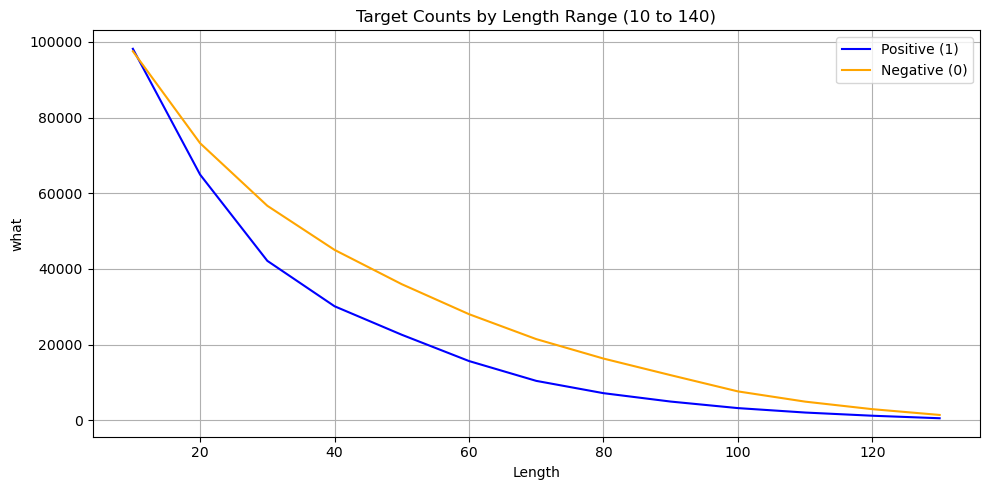

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
plt.plot(result['length'], result['positive'], label='Positive (1)', color='blue')
plt.plot(result['length'], result['negative'], label='Negative (0)', color='orange')
plt.title('Target Counts by Length Range (10 to 140)')
plt.xlabel('Length')
plt.ylabel('what')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 리뷰 적으러 오는건 좋은말  하러 오는건 아니구나...확인
#### 역시 리뷰남기는거 정말 귀찮은데 그것마저 뛰어넘을정도로 화나서 적으러 왔구나...

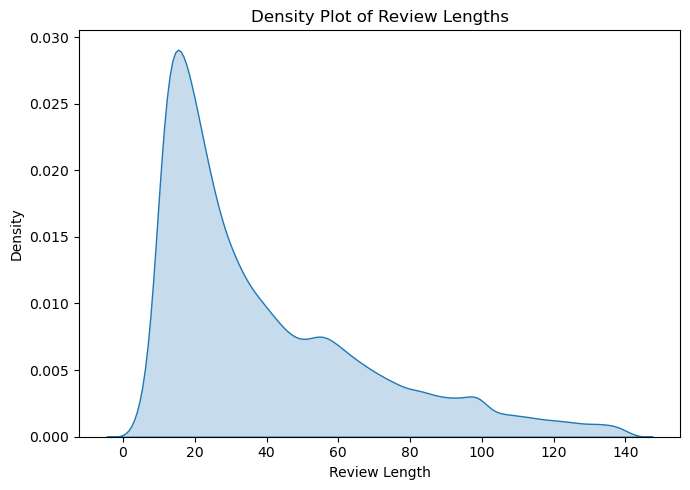

In [24]:
#리뷰 길이가 중요한 피처가 될 수 있다고 생각해서 밀도 확인

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.kdeplot(df['length'], fill=True)
plt.title('Density Plot of Review Lengths')
plt.xlabel('Review Length')
plt.ylabel('Density')
plt.tight_layout()
plt.show()


### 길이가 긴 것들은 따로 처리가 필요할 수 있겠다 생각정도만 하고 넘어감

## 2. 리뷰 토큰화

In [25]:
pd.set_option('display.max_colwidth', None)

In [26]:
df[(df['length']>=140)]

,rating,review,target,length,label
645,1,재구매 일딴 잘 떨어집니다. 그리고 내구력이 약하다보니깐 운정하고 어느순간 보시면 도어가드 몰딩이 떨어져 있는걸 확인 할수 있을꺼에요. 크롬이라서 이쁘긴 하지만 굴곡에서는 끼어지지도 않고 구부러진다는.. 한달 그냥 쓰다가 버리고 다른 재품으로 샀어요.,0,140,0
2229,5,장거리 배송에도 엄청 싱싱하고 건강하게 도착한 꽃이 너무 예쁘네요♡ 장미는 처음이라 손질하는 법도 잘 몰라서 걱정했는데요~ 도착하자마자 수분 듬뿍 주었더니 하루하루 활짝 피어나네요 :) 신경 많이 써주신 것에 감사합니다~ 신뢰100% 그림같이 이뻐요♡,1,140,1
3356,1,1. 배송전 제단 길이 첨부해도 참고안함. 지멋대로 제단해서보냄 2. 오배송되서 고객센터에 전화하면 상담원이 굉장히 불친절함(오히려 큰소리침) 3. 택배사가 다 다른업체에서 배송이 되며 시간이 제각각임 딴건 다필요없이 상담사때문에 기분이 굉장히 불쾌함,0,140,0
3449,5,어제 배송 도착 해서 오늘 사용 했는데 아침 출근때 부터 퇴근한 지금 까지도 계속 따듯해요 . 원래 얼마나 따듯하겠어 하고 사용 안했었는데 신세계 입니다 ㅎㅎㅎ 주머니에 넣고 다니면서 손시릴때 만지작 만지작하고 배에도 하나 딱 붙이니까 천국입니다 ㅎㅎ,1,140,1
3644,2,아의자 육각이가 자꾸 돌릴때마다 무뎌져서 힘들었고요 ㅠ 생각보다견고한느낌이아니에요 ㅠㅠ 흔들려서 오래사용하긴 좀힘들것같아요 저렴한거 알고사긴했는데 후기가 워낙좋아서 괜찮은가보다했는데 ..솔직히.. 조금 그르네요 ㅜ 왠만하면 환불안해서 걍 막쓰려구요 ㅠ,0,140,0
...,...,...,...,...,...
195891,2,1박2일이지만 전날 저녁6.7시에 택배가와서 퇴근후 측정하는데 매트리스.베게 1시간씩만해도 시간이모자라요..... 글고 담날 출근할때가져가서 택배보내야하고.... 주말로할려니 돈이아깝고 몰랐는데 다른대여방법도 있더라구요. 여유있게 하는게좋을거같아요..,0,140,0
197249,5,김장김치가 똑 김장김치를 다먹어서 검색하다가 후기믿고 주문했습니다 배송도 빠르고 깔끔하게 국물새지 않게 꼼꼼히 포장되어서 왔네요 포장여니 시큼한 냄새가나서 김치가 익었나싶었는데...맛보니 아삭하고 전혀 익은김치가 아니네요 맛있어서 담에 또 주문할꺼에요,1,140,1
197426,1,"마트에서 사서쓰던거랑 질감느낌이 달라요 저는맨날 이것만 사서썻는대 이번엔 귀찮아서 인터넷으로 시켯는데 마트꺼랑차이는 색은비슷한데 펄이들어갓다고해야하나 케라시스나 미쟝센같은 느낌으로 왓어요 원래 펄이없고 무광인데 펄이 들어잇는,,,쿨링효과는 잇긴잇습니다",0,140,0
198023,1,배송 정말 엉망이에요.. 하도 기다리다 안와서 전화했더니..송장번호를 문자로 달라고 하시는데...판매자측에서 주문자 정보를 조회해서 확인해주셔야되는거 아닌가요..결국엔 분실됬다고...다시 재발송...그거에 대한 피드백도 없고.. 정말 기분 별로네요..,0,140,0


In [15]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("beomi/KcELECTRA-base")
print(len(tokenizer.encode('배송 정말 엉망이에요.. 하도 기다리다 안와서 전화했더니..송장번호를 문자로 달라고 하시는데...판매자측에서 주문자 정보를 조회해서 확인해주셔야되는거 아닌가요..결국엔 분실됬다고...다시 재발송...그거에 대한 피드백도 없고.. 정말 기분 별로네요..')))

c:\Users\hhhmh\anaconda3\envs\machine_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


62


#### 여기서 계산해봐야... tokenizer로 계산하면 결과가 나온다는것을 알아버렸다..

In [27]:
from transformers import AutoTokenizer, AutoModel

X = df['review'].astype(str).tolist()
y = df['label']
  
tokenizer = AutoTokenizer.from_pretrained("beomi/KcELECTRA-base")
model = AutoModel.from_pretrained("beomi/KcELECTRA-base")

tokenized_X = tokenizer(X, truncation=True, padding=True)
tokenized_X['label'] = y.tolist()

#### 토큰화 결과로 최대 토큰수 129에 맞춰서 패딩처리되었다
#### 훈련데이터 나누기

In [28]:
from datasets import Dataset

dataset = Dataset.from_dict(tokenized_X)


# 학습/테스트 데이터 분리
train_test_split = dataset.train_test_split(test_size=0.2, seed=44)
train_dataset = train_test_split['train']
test_dataset = train_test_split['test']

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score
import torch


# 모델 로드
model = AutoModelForSequenceClassification.from_pretrained("beomi/KcELECTRA-base", num_labels=2)



# 정확도 계산 함수 정의
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.argmax(torch.tensor(logits), dim=-1).numpy()
    return {"accuracy": accuracy_score(labels, predictions)}



# TrainingArguments 설정
training_args = TrainingArguments(
    output_dir='./results',          # 출력 디렉토리
    num_train_epochs=3,             # 총 학습 epoch 수
    per_device_train_batch_size=16, # 학습 배치 크기
    per_device_eval_batch_size=16,  # 평가 배치 크기
    warmup_steps=500,               # 워밍업 단계 수
    weight_decay=0.01,              # 가중치 감쇠 값
    logging_dir='./logs',           # 로그 저장 디렉토리
    logging_steps=100,              # 로그 출력 빈도
    evaluation_strategy="epoch"     # 매 epoch마다 평가 수행
)

# Trainer 생성
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# 학습 시작
trainer.train()

# 모델 저장
trainer.save_model('./saved_model')


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at beomi/KcELECTRA-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.231500,0.236737
2,0.197700,0.208289
3,0.100200,0.212691


#### 트러블
hugging face에서는 타겟값을 label로 설정해야한다.
target으로 했다가 못알아먹어서 찾아보고 label로 바꿈

In [30]:
# 테스트 데이터셋 평가
eval_results = trainer.evaluate(eval_dataset=test_dataset)

# 결과 출력
print("Evaluation Results:")
print(eval_results)

Evaluation Results:
{'eval_loss': 0.2126912772655487, 'eval_runtime': 238.9599, 'eval_samples_per_second': 167.392, 'eval_steps_per_second': 10.462, 'epoch': 3.0}


In [ ]:
import torch
from transformers import AutoTokenizer

# 테스트할 문장
test_sentence = "최소 10자 이상.. 3일 사용해보고 리뷰..."

# 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained("beomi/KcELECTRA-base")

# 문장 토큰화
inputs = tokenizer(test_sentence, return_tensors="pt", truncation=True, padding=True)

# 디바이스 설정 (GPU가 사용 가능하면 GPU, 아니면 CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델을 디바이스로 이동
model.to(device)

# 입력 데이터를 디바이스로 이동
inputs = {key: value.to(device) for key, value in inputs.items()}

# 모델 예측
model.eval()  # 평가 모드로 변경
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

# 로짓을 소프트맥스 함수로 변환하여 확률 계산
probs = torch.nn.functional.softmax(logits, dim=-1)
predicted_class = torch.argmax(probs).item()

# 결과 출력
if predicted_class == 1:
    print(f"문장: \"{test_sentence}\" -> 긍정 (확률: {probs[0][1].item():.4f})")
else:
    print(f"문장: \"{test_sentence}\" -> 부정 (확률: {probs[0][0].item():.4f})")


문장: "이거...진짜...좋아요..." -> 긍정 (확률: 0.9320)


In [ ]:
from sklearn.metrics import accuracy_score
import torch

# 정확도 계산 함수 정의
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.argmax(torch.tensor(logits), dim=-1).numpy()
    return {"accuracy": accuracy_score(labels, predictions)}



# Trainer 생성 시 compute_metrics 추가
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics  # 정확도 계산 함수 추가
)

# 평가 수행
eval_results = trainer.evaluate()
print("Evaluation Results:")
print(eval_results)  # 정확도 포함된 결과 출력


Evaluation Results:
{'eval_loss': 0.2126912772655487, 'eval_model_preparation_time': 0.004, 'eval_accuracy': 0.9382, 'eval_runtime': 244.1444, 'eval_samples_per_second': 163.837, 'eval_steps_per_second': 10.24}


### koNLP로 형태소 분석 후 토큰화 해서 성능 비교해보기 

In [28]:
test_df = df[:10]
test_df

,rating,review,target,length,label
0,5,배공빠르고 굿,1,7,1
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,0,29,0
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 엉성하긴 하지만 편하고 가성비 최고예요.,1,68,1
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전화했더니 바로주신다했지만 배송도 누락되어있었네요.. 확인안하고 바로 선물했으면 큰일날뻔했네요..이렇게 배송이 오래걸렸으면 사는거 다시 생각했을거같아요 아쉽네요..,0,136,0
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,1,33,1
5,2,비추합니다 계란 뒤집을 때 완전 불편해요 ㅠㅠ 코팅도 묻어나고 보기엔 예쁘고 실용적으로 보였는데 생각보다 진짜 별로입니다.,0,68,0
6,1,주문을 11월6에 시켰는데 11월16일에 배송이 왔네요 ㅎㅎㅎ 여기 회사측과는 전화도 안되고 아무런 연락을 받을수가 없으니 답답하신 분들은 다른곳에서 사시는거 추천드립니다,0,95,0
7,2,넉넉한 길이로 주문했는데도 안 맞네요 별로예요,0,25,0
8,2,보폴이 계속 때처럼 나오다가 지금은 안나네요~,0,25,0
9,2,110인데 전문속옷브랜드 위생팬티105보다 작은듯해요. 불편해요. 밴딩부분이 다 신축성없는 일반실로 되어있어 빅사이즈임에도 빅사이즈같지않아요. 입고벗을때 편하게 밴딩부분이 늘어나고 입었을때도 밴딩이 잡아주어야하는데 말이죠.,0,124,0


In [30]:
from konlpy.tag import Kkma, Hannanum, Komoran, Okt
hannanum = Hannanum()
kkma = Kkma()
komoran = Komoran()
okt = Okt()

for sentence in test_df['review']:
  # hannanum : KAIST SWRC(Semantic Web Research Center)에서 개발
  print(f'Hannanum 형태소 분석기: {hannanum.morphs(sentence)}')

  # KKma : 서울대학교 IDS(intelligent Data Systems) 연구실에서 개발
  print(f'KKma 형태소 분석기: {kkma.morphs(sentence)}')

  # Komoran
  print(f'Komoran 형태소 분석기: {komoran.morphs(sentence)}')

  # okt: 오픈 소스 한국어 분석기, 과거 트위터 형태소 분석기
  print(f'okt 형태소 분석기: {okt.morphs(sentence)}')
  print('===========================================')

Hannanum 형태소 분석기: ['배공빠르', '이', '고', '굿']
KKma 형태소 분석기: ['배', '공', '빠르', '고', '굿']
Komoran 형태소 분석기: ['배', '공', '빠르', '고', '굿']
okt 형태소 분석기: ['배공', '빠르고', '굿']
Hannanum 형태소 분석기: ['택배', '가', '엉망이네용', '저희집', '밑에층', '에', '말도없', '이', '놔두', '고', '가', '고']
KKma 형태소 분석기: ['택배', '가', '엉망', '이', '네요', '저희', '집', '밑', '에', '층', '에', '말', '도', '없이', '놔두', '고', '가', '고']
Komoran 형태소 분석기: ['택배', '가', '엉망', '이', '네', '용', '저희', '집', '밑', '에', '층', '에', '말', '도', '없이', '놓아두', '고', '가', '고']
okt 형태소 분석기: ['택배', '가', '엉망', '이네', '용', '저희', '집', '밑', '에', '층', '에', '말', '도', '없이', '놔두고가고']
Hannanum 형태소 분석기: ['아주좋아요', '바', '이', '지', '정말', '좋아서2개', '더', '구매', '하', '었어', '요', '이가격', '에', '대박', '이', 'ㅂ니다', '.', '바느질', '이', '조금', '엉성하긴', '하', '지만', '편하', '어', '고', '가성비', '최고', '이', '예요', '.']
KKma 형태소 분석기: ['아주', '좋', '아요', '바지', '정말', '좋', '아서', '2', '개', '더', '구매', '하', '었', '어요', '이', '가격', '에', '대박', '이', 'ㅂ니다', '.', '바느질', '이', '조금', '엉성', '하', '기', '는', '하', '지만', '편하', '고', '가', '아', '성비', '최고', '이', '

#### 형태소 분석 결과 okt형태소 분석기가 가장 단여형태를 잘 유지하면서 자르고, 불필요 하게 길이가 길어지지않아서 토큰화 할때도 괜찮다고 판단

In [31]:
from konlpy.tag import  Okt

okt = Okt()

df['okt_tokenized'] = df['review'].apply(lambda x: okt.morphs(x))
df.head()

,rating,review,target,length,label,okt_tokenized
0,5,배공빠르고 굿,1,7,1,"[배공, 빠르고, 굿]"
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,0,29,0,"[택배, 가, 엉망, 이네, 용, 저희, 집, 밑, 에, 층, 에, 말, 도, 없이, 놔두고가고]"
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 엉성하긴 하지만 편하고 가성비 최고예요.,1,68,1,"[아주, 좋아요, 바지, 정말, 좋아서, 2, 개, 더, 구매, 했어요, 이, 가격, 에, 대박, 입니다, ., 바느질, 이, 조금, 엉, 성하긴, 하지만, 편하고, 가성, 비, 최고, 예요, .]"
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전화했더니 바로주신다했지만 배송도 누락되어있었네요.. 확인안하고 바로 선물했으면 큰일날뻔했네요..이렇게 배송이 오래걸렸으면 사는거 다시 생각했을거같아요 아쉽네요..,0,136,0,"[선물, 용, 으로, 빨리, 받아서, 전달, 했어야, 하는, 상품, 이었는데, 머그컵, 만, 와서, 당황, 했습니다, ., 전화했더니, 바로, 주신다, 했지만, 배송, 도, 누락, 되어있었네요, .., 확인, 안, 하고, 바로, 선물, 했으면, 큰일, 날, 뻔했네요, .., 이렇게, 배송, 이, 오래, 걸렸으면, 사는거, 다시, 생각, 했을거, 같아요, 아쉽네요, ..]"
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,1,33,1,"[민트, 색상, 예뻐요, ., 옆, 손잡이, 는, 거, 는, 용, 도로, 도, 사용, 되네요, ㅎㅎ]"


In [32]:
df['joined_reviews'] = df['okt_tokenized'].apply(lambda tokens: ' '.join(tokens))
df.head()

,rating,review,target,length,label,okt_tokenized,joined_reviews
0,5,배공빠르고 굿,1,7,1,"[배공, 빠르고, 굿]",배공 빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,0,29,0,"[택배, 가, 엉망, 이네, 용, 저희, 집, 밑, 에, 층, 에, 말, 도, 없이, 놔두고가고]",택배 가 엉망 이네 용 저희 집 밑 에 층 에 말 도 없이 놔두고가고
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 엉성하긴 하지만 편하고 가성비 최고예요.,1,68,1,"[아주, 좋아요, 바지, 정말, 좋아서, 2, 개, 더, 구매, 했어요, 이, 가격, 에, 대박, 입니다, ., 바느질, 이, 조금, 엉, 성하긴, 하지만, 편하고, 가성, 비, 최고, 예요, .]",아주 좋아요 바지 정말 좋아서 2 개 더 구매 했어요 이 가격 에 대박 입니다 . 바느질 이 조금 엉 성하긴 하지만 편하고 가성 비 최고 예요 .
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전화했더니 바로주신다했지만 배송도 누락되어있었네요.. 확인안하고 바로 선물했으면 큰일날뻔했네요..이렇게 배송이 오래걸렸으면 사는거 다시 생각했을거같아요 아쉽네요..,0,136,0,"[선물, 용, 으로, 빨리, 받아서, 전달, 했어야, 하는, 상품, 이었는데, 머그컵, 만, 와서, 당황, 했습니다, ., 전화했더니, 바로, 주신다, 했지만, 배송, 도, 누락, 되어있었네요, .., 확인, 안, 하고, 바로, 선물, 했으면, 큰일, 날, 뻔했네요, .., 이렇게, 배송, 이, 오래, 걸렸으면, 사는거, 다시, 생각, 했을거, 같아요, 아쉽네요, ..]",선물 용 으로 빨리 받아서 전달 했어야 하는 상품 이었는데 머그컵 만 와서 당황 했습니다 . 전화했더니 바로 주신다 했지만 배송 도 누락 되어있었네요 .. 확인 안 하고 바로 선물 했으면 큰일 날 뻔했네요 .. 이렇게 배송 이 오래 걸렸으면 사는거 다시 생각 했을거 같아요 아쉽네요 ..
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,1,33,1,"[민트, 색상, 예뻐요, ., 옆, 손잡이, 는, 거, 는, 용, 도로, 도, 사용, 되네요, ㅎㅎ]",민트 색상 예뻐요 . 옆 손잡이 는 거 는 용 도로 도 사용 되네요 ㅎㅎ


In [33]:
from transformers import AutoTokenizer, AutoModel

X = df['joined_reviews'].astype(str).tolist()
y = df['label']
  
tokenizer = AutoTokenizer.from_pretrained("beomi/KcELECTRA-base")
model = AutoModel.from_pretrained("beomi/KcELECTRA-base")

tokenized_X = tokenizer(X, truncation=True, padding=True)
tokenized_X['label'] = y.tolist()

In [34]:
from datasets import Dataset

dataset = Dataset.from_dict(tokenized_X)


# 학습/테스트 데이터 분리
train_test_split = dataset.train_test_split(test_size=0.2, seed=44)
train_dataset = train_test_split['train']
test_dataset = train_test_split['test']

In [35]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

# 평가 지표 계산 함수 정의
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis=-1)
  precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
  acc = accuracy_score(labels, predictions)
  return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

In [36]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 모델 로드
model = AutoModelForSequenceClassification.from_pretrained("beomi/KcELECTRA-base", num_labels=2)

# TrainingArguments 설정
training_args = TrainingArguments(
  output_dir='./results',          # 출력 디렉토리
    num_train_epochs=3,             # 총 학습 epoch 수
    per_device_train_batch_size=16, # 학습 배치 크기
    per_device_eval_batch_size=16,  # 평가 배치 크기
    warmup_steps=500,               # 워밍업 단계 수
    weight_decay=0.01,              # 가중치 감쇠 값
    logging_dir='./logs',           # 로그 저장 디렉토리
    logging_steps=100,              # 로그 출력 빈도
    eval_strategy="epoch",          # 평가 주기: epoch 단위
    save_strategy="epoch",          # 저장 주기: epoch 단위 (eval_strategy와 동일하게 설정)
    load_best_model_at_end=True,    # 최적 모델 자동 로드
    metric_for_best_model="accuracy", # 최고모델 기준(정확도)
)

#early_stopping설정
early_stopping_callback = EarlyStoppingCallback(early_stopping_patience=3)

# Trainer 생성
trainer = Trainer(
  model=model,
  args=training_args,
  train_dataset=train_dataset,
  eval_dataset=test_dataset,
  compute_metrics=compute_metrics,
  callbacks=[early_stopping_callback]
)

# 학습 시작
trainer.train()

# 모델 저장
trainer.save_model('./saved_model/okt')


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at beomi/KcELECTRA-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.208900,0.210722,0.934125,0.934415,0.926688,0.942272
2,0.202700,0.205661,0.938175,0.938340,0.932181,0.944581
3,0.094700,0.228901,0.939275,0.939431,0.933356,0.945585


In [37]:
# 테스트 데이터셋 평가
eval_results = trainer.evaluate(eval_dataset=test_dataset)

# 결과 출력
print("Evaluation Results:")
print(eval_results)

Evaluation Results:
{'eval_loss': 0.22890102863311768, 'eval_accuracy': 0.939275, 'eval_f1': 0.939430965264444, 'eval_precision': 0.9333564562481419, 'eval_recall': 0.9455850609909141, 'eval_runtime': 300.4631, 'eval_samples_per_second': 133.128, 'eval_steps_per_second': 8.32, 'epoch': 3.0}


In [ ]:
import torch
from transformers import AutoTokenizer

#모델 로드
model_path = './saved_model/okt/'
model =  AutoModelForSequenceClassification.from_pretrained(model_path)

# 테스트할 문장
test_sentence = "이 영화 정말 재미있어요"

# 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained("beomi/KcELECTRA-base")

# 문장 토큰화
inputs = tokenizer(test_sentence, return_tensors="pt", truncation=True, padding=True)

# 디바이스 설정 (GPU가 사용 가능하면 GPU, 아니면 CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델을 디바이스로 이동
model.to(device)

# 입력 데이터를 디바이스로 이동
inputs = {key: value.to(device) for key, value in inputs.items()}

# 모델 예측
model.eval()  # 평가 모드로 변경
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

# 로짓을 소프트맥스 함수로 변환하여 확률 계산
probs = torch.nn.functional.softmax(logits, dim=-1)
predicted_class = torch.argmax(probs).item()

# 결과 출력
if predicted_class == 1:
    print(f"문장: \"{test_sentence}\" -> 긍정 (확률: {probs[0][1].item():.4f})")
else:
    print(f"문장: \"{test_sentence}\" -> 부정 (확률: {probs[0][0].item():.4f})")


문장: "이 영화 정말 재미있어요" -> 긍정 (확률: 0.9850)
